# Sesi 1 — Dasar Python dan Pengolahan Citra Radiologi Dentomaksilofasial

**Praktikum Keterampilan Komputasi · PPDGS Radiologi Kedokteran Gigi · 150 menit · Tingkat Pemula**

Dalam sesi ini, kita akan belajar mengolah radiograf panoramik pediatrik yang bersumber dari dataset penelitian terbuka. Kita akan menggunakan kasus `test_cate1_001` sebagai studi kasus utama dan `test_cate1_012` sebagai bahan latihan mandiri/berpasangan.

> **Batasan Penggunaan:** Seluruh materi ini ditujukan khusus untuk pembelajaran komputasi dan audit teknis, bukan sebagai perangkat lunak diagnostik medis. Jangan pernah menggunakan keluaran notebook ini sebagai dasar pengambilan keputusan klinis atau perawatan pasien.

## Sasaran Belajar dan Kriteria Keberhasilan

Setelah menyelesaikan sesi ini, Anda diharapkan mampu:

1. Menjalankan sel-sel Google Colab secara berurutan dan membaca pesan kendala teknis (*error*) sederhana;
2. Memahami konsep variabel (*assignment*), senarai (*list*), penomoran indeks yang dimulai dari nol, pemanggilan fungsi, serta bentuk dimensi (*shape*) dan tipe data (*dtype*) citra;
3. Menghubungkan koordinat kotak pembatas `[x1, y1, x2, y2]` dengan teknik pemotongan array matriks (*slicing*) `[y1:y2, x1:x2]`;
4. Membandingkan citra asli, teknik *histogram equalization*, dan CLAHE secara kritis dan objektif; serta
5. Menjelaskan mengapa manipulasi kontras visual tidak menambah informasi diagnostik baru.

**Kriteria Keberhasilan:** Anda mampu mengganti ID kasus latihan, menentukan koordinat Region of Interest (ROI) yang valid (tidak kosong), serta menguraikan minimal satu manfaat klinis dan satu risiko teknis dari penerapan CLAHE.

## Agenda Praktikum (150 Menit)

| Alokasi Waktu | Topik & Kegiatan |
|---:|---|
| Menit 0–15 | Orientasi lingkungan kerja, panduan Google Colab, dan kepatuhan keamanan data |
| Menit 15–45 | Konsep dasar Python: variabel, `list`, penomoran indeks, fungsi, dan `print()` |
| Menit 45–75 | Citra panoramik (OPG) sebagai array matriks: `shape`, `dtype`, nilai piksel, dan histogram |
| Menit 75–90 | Istirahat sejenak dan evaluasi berkala (*checkpoint*) |
| Menit 90–115 | Bounding box, sistem koordinat, *Region of Interest* (ROI), dan pemotongan citra (*cropping*) |
| Menit 115–135 | Pengolahan kontras: perbandingan *Histogram Equalization* global vs. CLAHE |
| Menit 135–150 | Latihan mandiri kasus kedua dan pengisian tiket keluar (*exit ticket*) |

## Sebelum Mulai: Panduan Keamanan & Privasi Data Medis

- **Dilarang keras mengunggah radiograf riil milik pasien, nama, nomor rekam medis, tanggal lahir, maupun metadata DICOM ke Google Colab.**
- Gunakan hanya ID kasus publik yang telah disediakan secara resmi di dalam notebook ini.
- Status anonimisasi pada dataset riset terbuka tidak otomatis memberi izin hukum untuk memindahkan data klinis institusi lokal ke server *cloud*.
- Jika Anda memiliki keraguan terkait kebijakan institusi atau etika data, hentikan proses dan gunakan hanya berkas latihan lokal yang telah disetujui.

**Dataset Latihan:** Menggunakan [Children's Dental Panoramic Radiographs Dataset](https://doi.org/10.6084/m9.figshare.c.6317013.v1), dengan uraian protokol pengumpulan, proses anonimisasi, dan keterbatasan data yang dipublikasikan pada [artikel Scientific Data](https://doi.org/10.1038/s41597-023-02237-5). Berkas data dirilis dengan lisensi domain publik CC0, sedangkan artikel pendukungnya berlisensi CC BY 4.0. Asal-usul data (*provenance*) dan nilai *checksum* tiap citra tersimpan rapi di dalam berkas manifest repositori.

## Panduan Menjalankan Colab dan Mengatasi Error

1. Buka notebook ini di Google Colab, lalu pilih menu **Runtime → Restart session** untuk memulai dengan memori yang bersih.
2. Pilih **Runtime → Run all**. Tunggu hingga tanda putar pada setiap sel selesai dieksekusi secara berurutan.
3. Sel berlabel **▶ Jalankan** cukup dieksekusi langsung tanpa perlu diubah. Sel berlabel **✏ Ubah** sengaja disiapkan dengan 1–2 parameter aman untuk Anda coba modifikasi nilainya.
4. Jika muncul pesan `NameError`, hal itu umumnya berarti ada sel sebelumnya yang terlewat belum dijalankan: pilih menu **Runtime → Run all** kembali.
5. Jika proses unduhan aset gagal, periksa koneksi internet Anda lalu jalankan ulang sel kasus terkait. Sistem keamanan notebook ini akan otomatis menolak berkas yang memiliki nilai *checksum* tidak cocok.
6. Apabila terjadi kendala jaringan internet di ruang kelas, gunakan salinan berkas publik dan gambar acuan [`canonical_sesi1_overview.png`](../assets/pediatric_opg/canonical_sesi1_overview.png) yang dibagikan oleh pengajar. Gambar tersebut merupakan **keluaran acuan yang telah disimpan sebelumnya, bukan hasil komputasi langsung**—jangan pernah menggantinya dengan data pasien.

**Catatan Persiapan Pengajar (*Preflight*):** Buka notebook pada sesi Colab CPU yang baru, jalankan seluruh sel dari atas sampai bawah, lalu pastikan cadangan empat citra publik telah tersimpan di media penyimpanan lokal/USB kelas.

### ▶ Setup Virtual Environment (venv) & Kesiapan Pustaka

**Panduan untuk pengguna lokal (VS Code / Terminal):**
1. **Buat virtual environment** (opsional namun sangat disarankan):
   - **Windows:** `python -m venv .venv`
   - **macOS/Linux:** `python3 -m venv .venv`
2. **Aktifkan venv:**
   - **Windows:** `.venv\Scripts\activate`
   - **macOS/Linux:** `source .venv/bin/activate`
3. **Pilih kernel Python** dari `.venv` tersebut pada editor Anda.

Sel di bawah ini secara otomatis memeriksa dan menginstal pustaka yang dibutuhkan (`NumPy`, `OpenCV`, `Matplotlib`, `Pillow`) ke dalam lingkungan yang sedang aktif.

In [1]:
import importlib.util
import subprocess
import sys

# Daftar pustaka yang dibutuhkan pada Sesi 1
REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "PIL": "pillow",
}

missing_packages = [
    pip_name
    for mod_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(mod_name) is None
]

if missing_packages:
    print(f"Menginstal pustaka yang belum tersedia: {', '.join(missing_packages)}...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )
    print("Semua pustaka berhasil dipasang.")

# Verifikasi status lingkungan Python aktif
is_venv = sys.prefix != getattr(sys, "base_prefix", sys.prefix)
print("=== Status Lingkungan Python ===")
print("Interpreter :", sys.executable)
print("Virtual Env :", "Aktif (.venv)" if is_venv else "Sistem / Conda / Colab")
print("Pustaka Sesi 1 siap digunakan.")

=== Status Lingkungan Python ===
Interpreter : d:\PROJECT\fibonnaci\venv\Scripts\python.exe
Virtual Env : Aktif (.venv)
Pustaka Sesi 1 siap digunakan.


### ▶ Jalankan — Persiapan Lingkungan & Pustaka

Sel di bawah ini bertugas memeriksa kesiapan pustaka standar Python yang telah tersedia di Google Colab. Seluruh materi pada sesi ini dirancang ringan dan cukup dijalankan menggunakan CPU standar tanpa memerlukan GPU.

In [2]:
import hashlib, importlib.util, json, tempfile
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image

print("Lingkungan Python siap digunakan.")
print("NumPy:", np.__version__, "| OpenCV:", cv2.__version__)
print("Platform komputasi:", "Google Colab" if importlib.util.find_spec("google.colab") else "Komputer Lokal")

Lingkungan Python siap digunakan.
NumPy: 2.5.1 | OpenCV: 5.0.0
Platform komputasi: Komputer Lokal


## 1. Python Seperlunya: Objek → Fungsi → Keluaran

Program Python membaca dan mengeksekusi instruksi baris demi baris, dari atas ke bawah:

- Tanda sama dengan (`=`) bertugas menyimpan suatu nilai ke dalam nama variabel (*assignment*);
- Tanda kurung siku (`[]`) digunakan untuk membuat senarai (*list*) sekaligus memilih elemen di dalamnya;
- Penomoran indeks di Python selalu dimulai dari angka **0**, bukan 1;
- Penulisan `fungsi(argumen)` digunakan untuk menjalankan atau memanggil suatu fungsi; serta
- Perintah `print()` membantu kita memeriksa isi variabel maupun status berjalannya program.

Coba perhatikan kode di bawah ini, perkirakan apa teks yang akan tampil di layar, lalu jalankan selnya.

### ▶ Jalankan — Menyimpan Variabel (*Assignment*) dan Menampilkan Nilai dengan `print()`

In [3]:
modalitas = "radiograf panoramik"
jumlah_kasus = 4
ukuran_piksel = "8-bit"

print("Modalitas radiologi :", modalitas)
print("Jumlah kasus publik :", jumlah_kasus)
print("Format citra latihan:", ukuran_piksel)

Modalitas radiologi : radiograf panoramik
Jumlah kasus publik : 4
Format citra latihan: 8-bit


### ▶ Jalankan — Struktur Data `list` dan Penomoran Indeks Berbasis Nol

In [4]:
case_ids = ["test_cate1_001", "test_cate1_004", "test_cate1_012", "test_cate1_000"]

print("Elemen pada indeks ke-0 :", case_ids[0])
print("Elemen pada indeks ke-2 :", case_ids[2])
print("Total jumlah elemen     :", len(case_ids))

Elemen pada indeks ke-0 : test_cate1_001
Elemen pada indeks ke-2 : test_cate1_012
Total jumlah elemen     : 4


### ▶ Jalankan — Membuat dan Memanggil Fungsi

Dalam Python, baris kode yang menjorok ke dalam (memiliki indentasi) merupakan bagian isi dari sebuah fungsi. Fungsi sangat bermanfaat untuk merangkum langkah-langkah teknis yang panjang agar kode kita tetap terstruktur, rapi, dan mudah dipakai berulang kali.

In [5]:
def perkenalkan_kasus(case_id, modalitas):
    pesan = f"Kasus {case_id} merupakan contoh data publik untuk {modalitas}."
    return pesan

ringkasan = perkenalkan_kasus(case_ids[0], modalitas)
print(ringkasan)

Kasus test_cate1_001 merupakan contoh data publik untuk radiograf panoramik.


### 🩺 Diskusikan — Membaca Pesan Error sebagai Petunjuk Teknis

Ketika menemui kendala, pesan error Python bukanlah tanda kegagalan fatal, melainkan petunjuk teknis yang membantu kita memperbaikinya:

| Pesan Error | Arti / Penyebab Paling Sering | Langkah Penanganan Awal |
|---|---|---|
| `NameError` | Nama variabel atau fungsi belum dibuat/dieksekusi | Jalankan kembali sel-sel kode sebelumnya dari atas secara berurutan |
| `IndexError` | Nomor indeks yang dipanggil melebihi panjang `list` | Periksa jumlah elemen dengan `len(...)` dan ingat bahwa indeks dimulai dari 0 |
| `FileNotFoundError` | Berkas yang dicari belum ada di folder | Periksa koneksi internet atau cache lokal, lalu jalankan ulang sel pemuatan berkas |
| `RuntimeError: checksum` | Isi atau ukuran berkas berbeda dari dokumen resmi | Jangan dilanjutkan; unduh ulang salinan berkas publik yang valid |

💡 **Bahan Diskusi Singkat:**  
Menurut Anda, apa yang akan terjadi jika kita memanggil perintah `case_ids[4]`? Diskusikan jawabannya secara lisan atau perkirakan dalam hati sebelum mencoba menjalankannya.

### ✅ Checkpoint 1 — Refleksi Pemahaman Dasar

Tanpa melihat kembali catatan di atas, dapatkah Anda menunjukkan masing-masing satu contoh dari:

- Nama variabel;
- Struktur data `list`;
- Elemen pertama pada `list` menggunakan indeks; serta
- Pemanggilan suatu fungsi?

Bila salah satu dari keempat istilah ini masih terasa asing, luangkan waktu sejenak untuk meninjau kembali tiga sel kode di atas sebelum kita melangkah ke manipulasi citra.

## 2. Memuat Kasus Publik dengan Pemeriksaan Integritas Berkas

Modul-modul pembantu (*helper*) berikut bertugas mengunduh data publik, memverifikasi keutuhan berkas dengan sidik jari digital (SHA-256), serta menyediakan fungsi pemotongan (*cropping*) dan visualisasi.

### ▶ Jalankan — Konfigurasi Jalur Unduhan dan Direktori Cache Aset Publik

Menentukan alamat basis repositori publik resmi (`RAW_BASE`) dan folder penyimpanan sementara (`CACHE_DIR`) di komputer lokal atau Google Colab agar berkas citra tidak diunduh berulang kali.

In [6]:
RAW_BASE = (
    "https://raw.githubusercontent.com/kristonova/"
    "introduction-AI-coding-for-radiologist/main/assets/pediatric_opg"
)
CACHE_DIR = Path(tempfile.gettempdir()) / "dental_ai_lab_public_assets"

### ▶ Jalankan — Modul Pemeriksaan Sidik Jari Digital (`_sha256`)

Fungsi ini menghitung nilai *hash* kriptografis SHA-256 dari suatu berkas sebagai sidik jari digital unik. Jika berkas mengalami kerusakan transmisi atau diubah tanpa izin, nilai *hash* akan berbeda sehingga dapat langsung dideteksi.

In [7]:
def _sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

### ▶ Jalankan — Modul Penelusuran Direktori Aset (`_asset_roots`)

Fungsi ini menyusun daftar lokasi direktori lokal tempat berkas citra mungkin tersimpan, serta menambahkan folder cache sementara (`CACHE_DIR`).

In [8]:
def _asset_roots():
    roots = []
    here = Path.cwd().resolve()
    for base in [here, *list(here.parents)[:3]]:
        candidate = base / "assets" / "pediatric_opg"
        if candidate not in roots:
            roots.append(candidate)
    roots.append(CACHE_DIR)
    return roots

### ▶ Jalankan — Modul Pengunduhan Berkas yang Aman (`_download`)

Fungsi ini mengunduh berkas dari peladen daring dengan metode *atomic download* (menggunakan ekstensi sementara `.part` sebelum diubah menjadi berkas utuh). Bila proses unduhan terputus, sisa berkas rusak otomatis dihapus untuk mencegah korupsi data.

In [9]:
def _download(url, destination, timeout=30):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(destination.suffix + ".part")
    temporary.unlink(missing_ok=True)
    request = Request(url, headers={"User-Agent": "UGM-dental-AI-lab/1.0"})
    try:
        with urlopen(request, timeout=timeout) as response:
            temporary.write_bytes(response.read())
        temporary.replace(destination)
    except (HTTPError, URLError, TimeoutError, OSError) as exc:
        temporary.unlink(missing_ok=True)
        raise RuntimeError(
            "Unduhan aset publik gagal. Periksa koneksi internet Anda, lalu jalankan ulang sel. "
            "Jika kelas sedang berlangsung secara luring, gunakan salinan cache dari pengajar. "
            "Jangan mengunggah data pasien riil sebagai pengganti."
        ) from exc
    return destination

### ▶ Jalankan — Modul Pembacaan Manifest Data Publik (`_load_manifest`)

Fungsi ini memuat berkas manifest `cases.json` yang memuat metadata resmi kasus, nama berkas citra, *checksum* acuan, dan data anotasi. Jika belum ada di penyimpanan lokal, berkas manifest akan diunduh secara otomatis.

In [10]:
def _load_manifest():
    for root in _asset_roots():
        path = root / "cases.json"
        if path.exists():
            try:
                return json.loads(path.read_text(encoding="utf-8"))
            except (json.JSONDecodeError, OSError) as exc:
                raise RuntimeError(
                    f"Manifest tidak dapat dibaca: {path}. "
                    "Silakan unduh ulang berkas manifest publik dari repositori."
                ) from exc
    path = _download(f"{RAW_BASE}/cases.json", CACHE_DIR / "cases.json")
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError as exc:
        path.unlink(missing_ok=True)
        raise RuntimeError(
            "Berkas manifest hasil unduhan tidak valid dan telah dihapus. Silakan jalankan ulang sel."
        ) from exc

### ▶ Jalankan — Modul Ekstraksi Daftar Kasus dari Manifest (`_manifest_cases`)

Fungsi ini mengekstrak senarai catatan kasus dari struktur objek manifest yang telah dibaca.

In [11]:
def _manifest_cases(manifest):
    if isinstance(manifest, list):
        return manifest
    if isinstance(manifest, dict) and isinstance(manifest.get("cases"), list):
        return manifest["cases"]
    raise RuntimeError("Format manifest tidak dikenali: daftar 'cases' tidak ditemukan.")

### ▶ Jalankan — Modul Penyeragaman Format ID Kasus (`_normalise_case_id`)

Fungsi ini memastikan setiap identitas kasus memiliki format standar (menambahkan awalan `test_` secara otomatis bila pengguna hanya menuliskan nomor kasus).

In [12]:
def _normalise_case_id(case_id):
    case_id = str(case_id).strip()
    return case_id if case_id.startswith("test_") else f"test_{case_id}"

### ▶ Jalankan — Modul Pencarian Rekaman Metadata Kasus (`_find_record`)

Fungsi ini mencocokkan ID kasus yang diminta dengan rekaman pada manifest. Bila kasus tidak terdaftar, fungsi akan menampilkan daftar kasus publik yang valid.

In [13]:
def _find_record(case_id):
    wanted = _normalise_case_id(case_id)
    for record in _manifest_cases(_load_manifest()):
        candidate = _normalise_case_id(record.get("case_id", ""))
        if candidate == wanted:
            return record
    available = [
        _normalise_case_id(item.get("case_id", ""))
        for item in _manifest_cases(_load_manifest())
    ]
    raise ValueError(f"CASE_ID tidak ditemukan. Pilih salah satu kasus yang tersedia: {available}")

### ▶ Jalankan — Modul Pengambilan Nama Berkas Citra (`_record_filename`)

Fungsi ini mengekstrak nama berkas citra PNG yang tercatat di dalam metadata manifest.

In [14]:
def _record_filename(record):
    filename = (
        record.get("image")
        or record.get("image_filename")
        or record.get("filename")
    )
    if not filename:
        raise RuntimeError("Manifest tidak memuat nama berkas citra.")
    return Path(filename).name

### ▶ Jalankan — Modul Pengambilan Nilai SHA-256 Acuan (`_record_sha`)

Fungsi ini mengambil nilai sidik jari digital (SHA-256) resmi yang diharapkan untuk verifikasi keaslian citra.

In [15]:
def _record_sha(record):
    expected = record.get("sha256") or record.get("image_sha256")
    if not expected:
        raise RuntimeError("Manifest tidak memuat nilai SHA-256 citra; berkas tidak digunakan demi keamanan.")
    return str(expected).lower()

### ▶ Jalankan — Modul Verifikasi Integritas dan Pengambilan Jalur Citra (`_verified_image_path`)

Fungsi ini memastikan berkas citra yang akan digunakan benar-benar utuh dan cocok dengan nilai SHA-256 acuan. Jika berkas di penyimpanan lokal tidak cocok atau belum ada, berkas baru akan diunduh dan diverifikasi ulang secara ketat.

In [16]:
def _verified_image_path(record):
    filename = _record_filename(record)
    expected = _record_sha(record)
    mismatches = []
    for root in _asset_roots():
        path = root / filename
        if path.exists():
            actual = _sha256(path)
            if actual == expected:
                return path
            mismatches.append(f"{path} ({actual[:12]}...)")
            if root == CACHE_DIR:
                path.unlink(missing_ok=True)

    download_path = CACHE_DIR / filename
    try:
        _download(f"{RAW_BASE}/{filename}", download_path)
        actual = _sha256(download_path)
        if actual != expected:
            download_path.unlink(missing_ok=True)
            raise RuntimeError(
                "Checksum citra hasil unduhan tidak cocok. Berkas telah dihapus secara otomatis; "
                "notebook tidak akan melanjutkan dengan salinan yang tidak valid."
            )
        return download_path
    except RuntimeError as exc:
        detail = f" Salinan lokal yang ditolak: {mismatches}." if mismatches else ""
        raise RuntimeError(f"{exc}{detail}") from exc

### ▶ Jalankan — Modul Normalisasi Koordinat Anotasi Bounding Box (`_annotations`)

Fungsi ini membaca data koordinat kotak pembatas (*bounding box*) `[x1, y1, x2, y2]` serta label kelainan dari manifest, lalu menormalkannya ke format standar yang siap divisualisasikan.

In [17]:
def _annotations(record):
    items = record.get("annotations") or record.get("labels") or []
    normalised = []
    for item in items:
        box = item.get("bbox_xyxy")
        if not isinstance(box, list) or len(box) != 4:
            continue
        normalised.append(
            {
                "bbox_xyxy": [float(value) for value in box],
                "label_id": (
                    item.get("label_indonesia")
                    or item.get("label_idn")
                    or item.get("label_id")
                    or "Label publik"
                ),
                "label_en": (
                    item.get("label_en")
                    or item.get("label_english")
                    or item.get("label_inggris")
                    or ""
                ),
            }
        )
    return normalised

### ▶ Jalankan — Modul Utama Pemuatan Kasus Terverifikasi (`load_case`)

Fungsi utama yang memanggil seluruh alur verifikasi di atas: mencari rekaman kasus, memvalidasi keutuhan berkas, memuat citra ke dalam array NumPy RGB 8-bit, serta mengemas informasi kasus, citra, dan anotasi ke dalam sebuah kamus (*dictionary*).

In [18]:
def load_case(case_id):
    """Muat satu kasus publik terverifikasi sebagai array RGB uint8."""
    record = _find_record(case_id)
    path = _verified_image_path(record)
    try:
        image = np.asarray(Image.open(path).convert("RGB"))
    except (OSError, ValueError) as exc:
        if path.parent == CACHE_DIR:
            path.unlink(missing_ok=True)
        raise RuntimeError(
            "Citra tidak dapat dibaca. Berkas cache yang bermasalah tidak akan digunakan."
        ) from exc

    if image.ndim != 3 or image.shape[2] != 3 or image.dtype != np.uint8:
        raise RuntimeError("Format aset tidak sesuai: diharapkan format PNG RGB 8-bit.")
    return {
        "case_id": _normalise_case_id(record.get("case_id", case_id)),
        "image": image,
        "annotations": _annotations(record),
        "record": record,
        "path": str(path),
    }

### ▶ Jalankan — Modul Konversi Citra ke Grayscale (`_to_gray`)

Fungsi pembantu untuk mengonversi array citra RGB 3-kanal menjadi citra derajat keabuan (*grayscale*) 1-kanal `uint8` menggunakan pustaka OpenCV.

In [19]:
def _to_gray(image):
    array = np.asarray(image)
    if array.ndim == 2:
        return array.astype(np.uint8)
    if array.ndim == 3 and array.shape[2] == 3:
        return cv2.cvtColor(array.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    raise ValueError("Citra harus berupa array matriks grayscale atau RGB.")

### ▶ Jalankan — Modul Pembatasan dan Validasi Koordinat ROI (`_clip_roi`)

Fungsi pembantu untuk memvalidasi koordinat Region of Interest `[x1, y1, x2, y2]` agar tetap berada di dalam rentang batas dimensi citra dan tidak menghasilkan potongan kosong ($x_2 > x_1$ dan $y_2 > y_1$).

In [20]:
def _clip_roi(roi, width, height):
    if not isinstance(roi, (list, tuple)) or len(roi) != 4:
        raise ValueError("Format ROI harus berupa empat angka koordinat [x1, y1, x2, y2].")
    x1, y1, x2, y2 = [int(round(value)) for value in roi]
    x1, x2 = np.clip([x1, x2], 0, width)
    y1, y2 = np.clip([y1, y2], 0, height)
    if x2 <= x1 or y2 <= y1:
        raise ValueError(
            "Area ROI kosong setelah dibatasi ke ukuran citra. "
            "Pastikan nilai x2 > x1 dan y2 > y1."
        )
    return int(x1), int(y1), int(x2), int(y2)

### ▶ Jalankan — Modul Penggambaran Kotak Anotasi Acuan (`_draw_annotations`)

Fungsi pembantu untuk menggambar kotak pembatas merah (*ground truth*) beserta label lesi pada kanvas Matplotlib.

In [21]:
def _draw_annotations(axis, annotations):
    for annotation in annotations:
        x1, y1, x2, y2 = annotation["bbox_xyxy"]
        axis.add_patch(
            Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="#ff4d4d", linewidth=1.8
            )
        )
        axis.text(
            x1, max(0, y1 - 8), annotation["label_id"],
            color="white", fontsize=7,
            bbox={"facecolor": "#b30000", "alpha": 0.75, "pad": 1.5},
        )

### ▶ Jalankan — Modul Visualisasi Empat Panel ROI dan Nilai Matriks Piksel (`show_roi`)

Fungsi visualisasi komparatif yang menampilkan empat panel secara berdampingan: (1) citra panoramik utuh, (2) citra beranotasi acuan merah dan kotak ROI kuning, (3) hasil pemotongan area ROI (*crop*), serta (4) representasi nilai numerik piksel (0–255) pada petak matriks $8 \times 8$.

In [22]:
def show_roi(image, roi, annotations=None):
    """Tampilkan citra, anotasi, ROI, dan matriks piksel berdampingan."""
    array = np.asarray(image)
    height, width = array.shape[:2]
    x1, y1, x2, y2 = _clip_roi(roi, width, height)
    crop = array[y1:y2, x1:x2]
    gray_crop = _to_gray(crop)

    cy, cx = gray_crop.shape[0] // 2, gray_crop.shape[1] // 2
    py1, px1 = max(0, cy - 4), max(0, cx - 4)
    patch = gray_crop[py1:py1 + 8, px1:px1 + 8]

    figure, axes = plt.subplots(1, 4, figsize=(21, 5))
    axes[0].imshow(array)
    axes[0].set_title("1 · Citra Asli (Utuh)")
    axes[1].imshow(array)
    _draw_annotations(axes[1], annotations or [])
    axes[1].add_patch(
        Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor="#ffd400", linewidth=2.2
        )
    )
    axes[1].set_title("2 · Anotasi Merah + ROI Kuning")
    axes[2].imshow(crop)
    axes[2].set_title(f"3 · Hasil Crop [{y1}:{y2}, {x1}:{x2}]")
    axes[3].imshow(patch, cmap="gray", vmin=0, vmax=255)
    axes[3].set_title(f"4 · Nilai Piksel ({patch.shape[0]}×{patch.shape[1]})")

    for row in range(patch.shape[0]):
        for column in range(patch.shape[1]):
            value = int(patch[row, column])
            axes[3].text(
                column, row, value, ha="center", va="center",
                fontsize=7, color="black" if value > 145 else "white"
            )
    for axis in axes[:3]:
        axis.axis("off")
    axes[3].set_xticks([])
    axes[3].set_yticks([])
    plt.tight_layout()
    plt.show()
    return crop

### ▶ Jalankan — Modul Peningkatan Kontras Adaptif CLAHE (`apply_clahe`)

Fungsi untuk menerapkan perataan histogram lokal (*Contrast Limited Adaptive Histogram Equalization*) pada citra grayscale, dengan pembatasan penguatan kontras melalui parameter `clip_limit` agar derau tidak meningkat berlebihan.

In [23]:
def apply_clahe(image, clip_limit=2.0):
    """Terapkan CLAHE pada citra grayscale 8-bit."""
    if not 0.1 <= float(clip_limit) <= 10.0:
        raise ValueError("Nilai CLAHE_CLIP harus berada di antara rentang 0.1 dan 10.0.")
    gray = _to_gray(image)
    operator = cv2.createCLAHE(
        clipLimit=float(clip_limit), tileGridSize=(8, 8)
    )
    return operator.apply(gray)

### ▶ Jalankan — Modul Penampil Citra Berdampingan dengan Histogram (`_show_image_and_histogram`)

Fungsi visualisasi untuk menampilkan citra radiografi berdampingan dengan kurva histogram distribusi frekuensi derajat keabuan (0–255) masing-masing citra.

In [24]:
def _show_image_and_histogram(images, titles):
    figure, axes = plt.subplots(2, len(images), figsize=(17, 8))
    for column, (image, title) in enumerate(zip(images, titles)):
        axes[0, column].imshow(image, cmap="gray", vmin=0, vmax=255)
        axes[0, column].set_title(title)
        axes[0, column].axis("off")
        axes[1, column].hist(
            np.asarray(image).ravel(), bins=256, range=(0, 256), color="#315c9b"
        )
        axes[1, column].set_xlim(0, 255)
        axes[1, column].set_xlabel("Nilai Derajat Keabuan (0–255)")
        axes[1, column].set_ylabel("Frekuensi Piksel")
    plt.tight_layout()
    plt.show()

### ✏ Ubah — Menentukan Kasus Radiografi Utama

Pada percobaan pertama, biarkan nilai default ini apa adanya agar alur pembelajaran berjalan lancar. Setelah seluruh konsep dipahami, satu-satunya parameter di sel ini yang boleh Anda ganti adalah `CASE_ID`.

In [25]:
CASE_ID = "test_cate1_001"

if "load_case" not in globals():
    raise RuntimeError("Silakan jalankan sel setup dan helper terlebih dahulu.")
case = load_case(CASE_ID)
opg = case["image"]
print("Kasus siap:", case["case_id"])

Kasus siap: test_cate1_001


## 3. Radiograf Panoramik (OPG) sebagai Array Matriks

Bagi komputer, setiap citra digital dibaca sebagai susunan matriks angka (*array*). Pada citra berwarna berformat RGB, ukuran dimensi citra (*shape*) ditulis dalam urutan `(tinggi, lebar, kanal)`. Oleh karena itu, dimensi tinggi (jumlah baris vertikal) selalu ditulis mendahului dimensi lebar (jumlah kolom horizontal).

### ▶ Jalankan — Memeriksa `shape`, `dtype`, dan Rentang Nilai Piksel

In [26]:
if "opg" not in globals():
    raise RuntimeError("Kasus belum dimuat. Jalankan sel CASE_ID terlebih dahulu.")
print("Dimensi citra (shape) :", opg.shape)
print("Tipe data (dtype)     :", opg.dtype)
print("Rentang intensitas    :", int(opg.min()), "sampai", int(opg.max()))
print("Piksel di [y=400, x=800]:", opg[400, 800].tolist())

Dimensi citra (shape) : (942, 2000, 3)
Tipe data (dtype)     : uint8
Rentang intensitas    : 0 sampai 255
Piksel di [y=400, x=800]: [118, 118, 118]


### 🩺 Diskusikan — Membaca Struktur Dimensi Array Citra

Pada radiograf latihan ini, komputer melaporkan dimensi citra dengan tinggi sekitar 942 piksel, lebar 2.000 piksel, dan 3 kanal warna RGB. Karena aslinya merupakan radiograf panoramik hitam-putih, ketiga kanal pada berkas PNG ini memuat intensitas derajat keabuan yang serupa.

Prinsip penting yang perlu dipahami:
- Tipe data `uint8` (*unsigned 8-bit integer*) menunjukkan bahwa setiap kanal menyimpan bilangan bulat dari 0 hingga 255.
- Nilai angka piksel murni menggambarkan intensitas kecerahan pada citra digital, **bukan ukuran kuantitatif keparahan penyakit secara biologis**.
- Urutan indeks piksel pada array Python ditulis `[y, x]`, yang bersesuaian dengan kaidah matriks `[baris, kolom]`.

### ▶ Jalankan — Menampilkan Citra OPG Berdampingan dengan Histogramnya

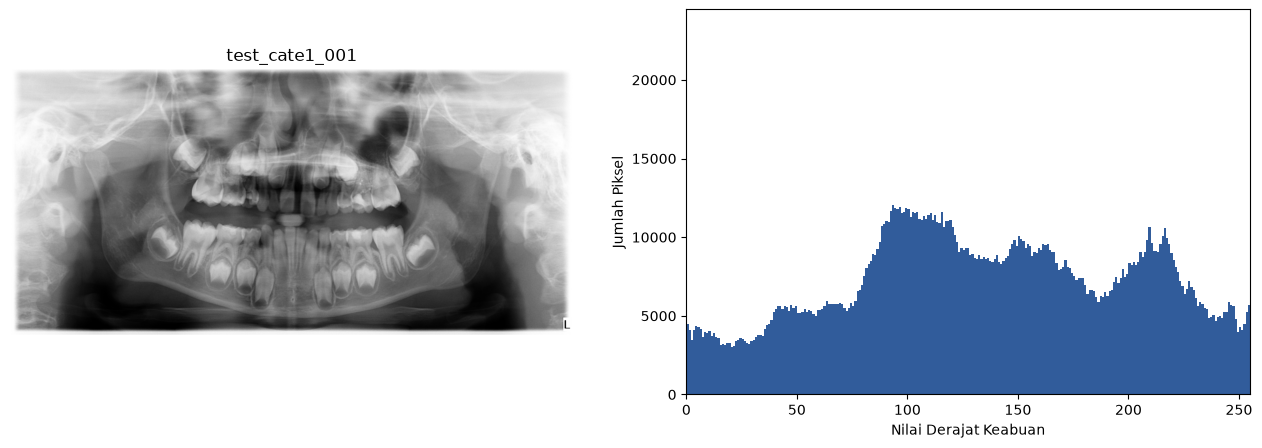

In [27]:
if "opg" not in globals():
    raise RuntimeError("Kasus belum dimuat. Jalankan sel CASE_ID terlebih dahulu.")
opg_gray = cv2.cvtColor(opg, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(opg_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(CASE_ID)
axes[0].axis("off")
axes[1].hist(opg_gray.ravel(), bins=256, range=(0, 256), color="#315c9b")
axes[1].set(xlim=(0, 255), xlabel="Nilai Derajat Keabuan", ylabel="Jumlah Piksel")
plt.show()

### 🩺 Diskusikan — Mengapa Histogram Tidak Mengenal Struktur Anatomi?

Histogram bertugas menghitung berapa banyak piksel yang berada pada masing-masing tingkat intensitas, namun **sama sekali mengabaikan posisi spasial dari piksel-piksel tersebut**.

Dua citra radiograf yang memiliki grafik histogram serupa dapat menunjukkan struktur anatomi atau temuan lesi yang jauh berbeda. Oleh karena itu, histogram sangat berguna untuk mengevaluasi kualitas kontras secara global, namun tidak dapat digunakan secara mandiri untuk menilai kondisi klinis pasien.

### ✅ Checkpoint 2 dan Istirahat Sejenak (Menit 75–90)

Sebelum beristirahat sejenak, diskusikan tiga pertanyaan berikut bersama rekan Anda:

1. Mengapa indeks `opg.shape[0]` merujuk pada ukuran tinggi citra?
2. Apa perbedaan mendasar antara informasi bentuk dimensi (`shape`) dan tipe data (`dtype`)?
3. Mengapa nilai intensitas piksel tidak boleh langsung ditafsirkan sebagai derajat keparahan penyakit?

Setelah waktu istirahat selesai, pastikan variabel kasus Anda masih aktif sebelum kita melanjutkan ke materi pemotongan citra.

## 4. Bounding Box, Region of Interest (ROI), dan Teknik Pemotongan (*Slicing*)

Dalam representasi data anotasi, kotak pembatas (*bounding box*) ditulis dalam format koordinat `[x1, y1, x2, y2]`:

- Titik `(x1, y1)` = sudut kiri atas kotak;
- Titik `(x2, y2)` = sudut kanan bawah kotak;
- Lebar area = `x2 - x1`; tinggi area = `y2 - y1`.

Sementara itu, pemotongan array matriks pada Python (*slicing*) selalu mengikuti urutan **baris terlebih dahulu, kemudian kolom**:

```python
crop = image[y1:y2, x1:x2]
```

Perhatikan bahwa nilai koordinat akhir `y2` dan `x2` tidak ikut diambil ke dalam potongan. Karakteristik ini dikenal sebagai batas akhir eksklusif (*exclusive upper bound*).

### ▶ Jalankan — Membaca Anotasi Publik dari Dataset

In [28]:
if "case" not in globals():
    raise RuntimeError("Kasus belum dimuat. Jalankan sel CASE_ID terlebih dahulu.")
print("Jumlah kotak anotasi (bounding box):", len(case["annotations"]))
for nomor, anotasi in enumerate(case["annotations"], start=1):
    box = [round(v) for v in anotasi["bbox_xyxy"]]
    print(nomor, anotasi["label_id"], box)

Jumlah kotak anotasi (bounding box): 4
1 Pit/fisur dalam [639, 295, 764, 492]
2 Karies [752, 371, 836, 500]
3 Karies [735, 538, 831, 681]
4 Karies [822, 552, 894, 678]


### ✏ Ubah — Menentukan Koordinat Region of Interest (ROI)

Jalankan sel ini terlebih dahulu dengan nilai default di bawah. Setelah tampilan citra muncul, cobalah mengubah **salah satu nilai koordinat saja**, jalankan ulang selnya, lalu amati ke arah mana kotak kuning dan hasil potongannya bergeser.

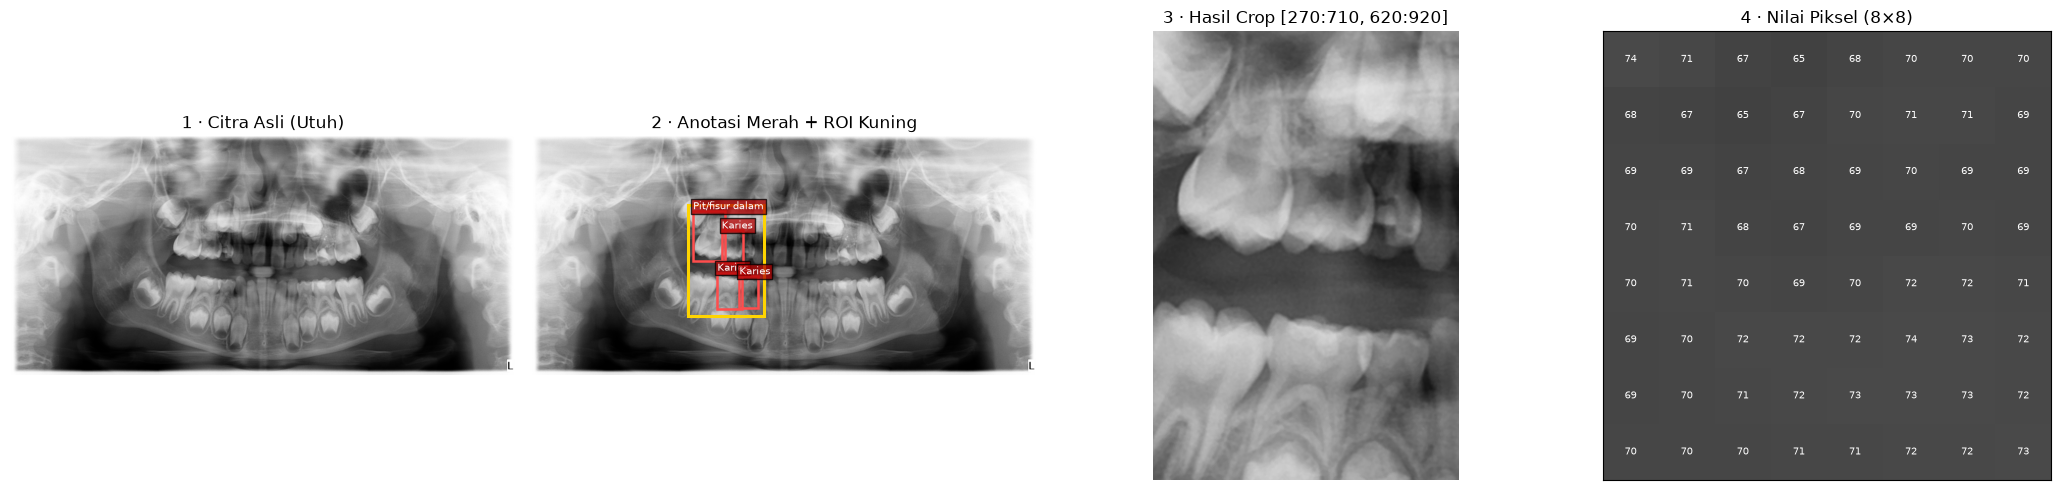

Dimensi area crop (tinggi, lebar, kanal): (440, 300, 3)


In [29]:
ROI = [620, 270, 920, 710]

if "show_roi" not in globals() or "opg" not in globals() or "case" not in globals():
    raise RuntimeError("Jalankan sel setup, helper, dan CASE_ID terlebih dahulu.")
roi_crop = show_roi(opg, ROI, case["annotations"])
print("Dimensi area crop (tinggi, lebar, kanal):", roi_crop.shape)

### ▶ Jalankan — Membuktikan Hubungan antara Koordinat ROI dan Sintaks Slicing

Perhatikan kontras polanya: penulisan koordinat ROI menggunakan urutan kartesius `x, y`, sedangkan sintaks pemotongan array matriks (*slicing*) di Python menggunakan urutan `y, x` (`[baris, kolom]`).

In [30]:
if "ROI" not in globals() or "opg" not in globals() or "roi_crop" not in globals():
    raise RuntimeError("ROI belum siap. Jalankan sel ROI terlebih dahulu.")
x1, y1, x2, y2 = ROI
roi_manual = opg[y1:y2, x1:x2]

print("Sintaks slicing:", f"opg[{y1}:{y2}, {x1}:{x2}]")
print("Apakah hasil slicing manual identik dengan helper?", np.array_equal(roi_crop, roi_manual))

Sintaks slicing: opg[270:710, 620:920]
Apakah hasil slicing manual identik dengan helper? True


### 🩺 Diskusikan — Mengapa Bounding Box Bukan Batas Biologis Lesi?

Kotak pembatas (*bounding box*) hanyalah simplifikasi geometris yang digambar oleh anotator:
- Kotak persegi pasti mengikutsertakan jaringan sehat di sekitar lesi dan tidak mengikuti batas margin patologis secara presisi;
- Terdapat variabilitas antarpengamat (*inter-observer variability*), di mana dua ahli radiologi bisa saja menggambar batas kotak yang sedikit berbeda;
- Tindakan memotong citra (*cropping*) menghilangkan konteks struktur anatomi di sekitarnya.

💡 **Bahan Diskusi:**  
Sebutkan satu skenario klinis di bidang radiologi kedokteran gigi di mana keberadaan struktur anatomi di luar area lesi (konteks sekitar) justru sangat penting untuk menentukan diagnosis atau rencana perawatan.

## 5. Peningkatan Kontras: Histogram Equalization vs. CLAHE

- **Histogram Equalization (Global):** Memetakan ulang kontras dengan memanfaatkan sebaran intensitas di seluruh citra secara bersamaan.
- **CLAHE (*Contrast Limited Adaptive Histogram Equalization*):** Bekerja secara adaptif pada blok-blok area kecil dan membatasi penguatan kontras agar derau (*noise*) tidak meningkat secara berlebihan.

Agar perbandingan visual dapat dinilai secara adil dan objektif, ketiga panel perbandingan di bawah ini dikunci pada skala rentang tampilan yang sama: 0–255.

### ✏ Ubah — Mengatur Kekuatan Kontras CLAHE (*Clip Limit*)

Jalankan sel ini terlebih dahulu dengan nilai default `2.0`. Setelah mengamati hasilnya, cobalah ubah nilainya menjadi `1.0` (penguatan lebih halus) atau `4.0` (penguatan lebih agresif). Parameter yang boleh Anda ganti di sel ini hanyalah `CLAHE_CLIP`.

In [31]:
CLAHE_CLIP = 2.0

if "apply_clahe" not in globals() or "opg" not in globals():
    raise RuntimeError("Jalankan sel setup, helper, dan CASE_ID terlebih dahulu.")
opg_clahe = apply_clahe(opg, CLAHE_CLIP)
print(f"Penerapan CLAHE selesai dengan clip limit: {CLAHE_CLIP}")

Penerapan CLAHE selesai dengan clip limit: 2.0


### ▶ Jalankan — Membandingkan Citra dan Histogram Sebelum serta Sesudah Pengolahan

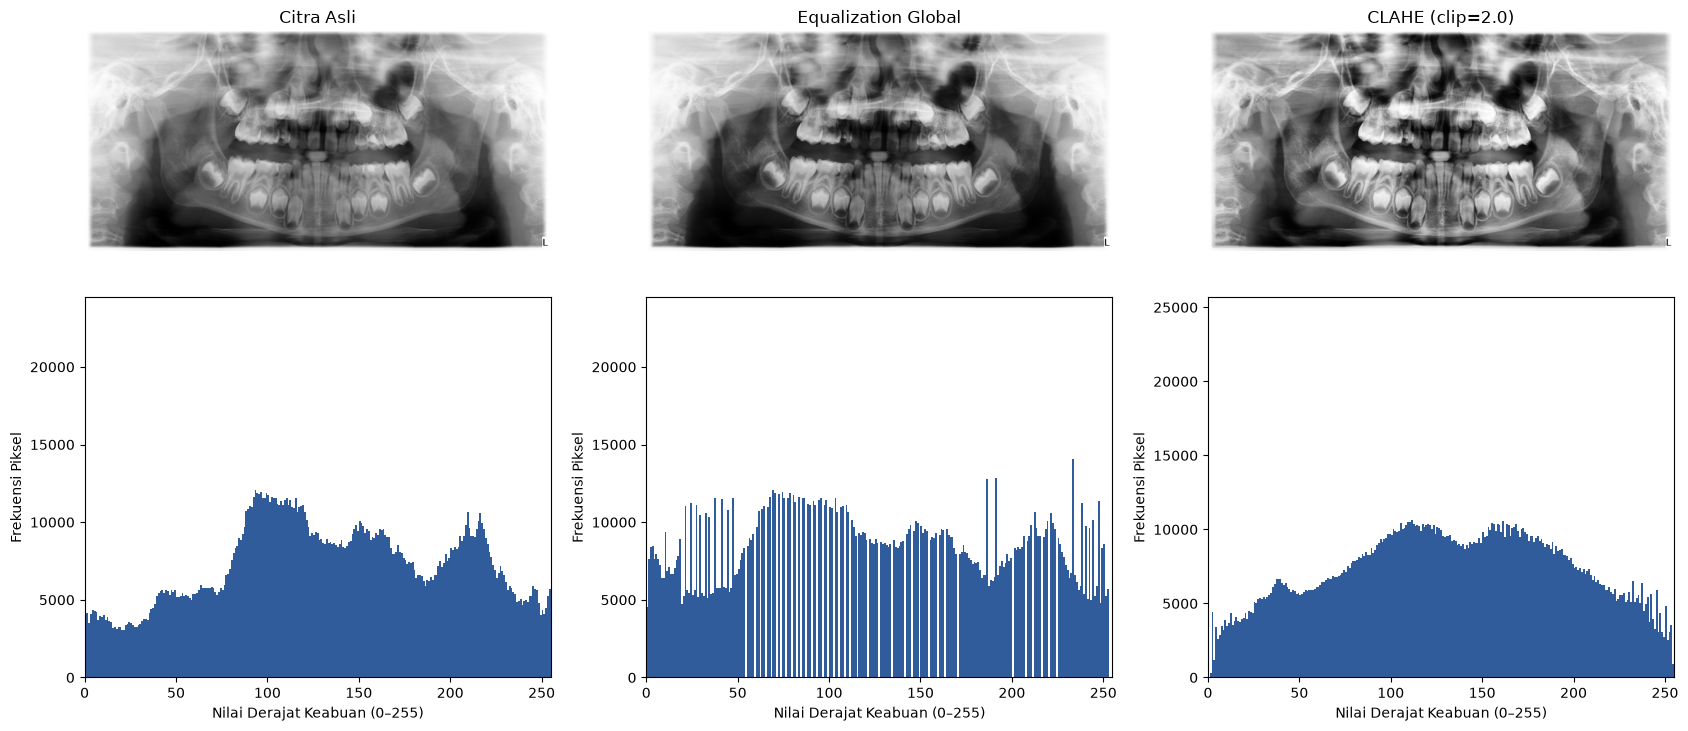

In [32]:
if "opg_gray" not in globals() or "opg_clahe" not in globals():
    raise RuntimeError("Jalankan sel histogram dan CLAHE terlebih dahulu.")
opg_equalized = cv2.equalizeHist(opg_gray)

_show_image_and_histogram(
    [opg_gray, opg_equalized, opg_clahe],
    ["Citra Asli", "Equalization Global", f"CLAHE (clip={CLAHE_CLIP})"],
)

### 🩺 Diskusikan — Mengubah Tampilan Visual Bukan Menambah Informasi Diagnostik Baru

Metode perataan histogram dan CLAHE sekadar memetakan ulang distribusi nilai intensitas agar pola tertentu lebih mudah tertangkap oleh mata. Namun, penting untuk dipahami bahwa kedua metode ini:

- Dapat memperjelas derau (*noise*), butiran (*grain*), atau artefak yang semula tidak terlalu mencolok;
- Dapat membuat batas struktur terlihat lebih tegas tanpa menambah sinyal foton baru yang memang tidak sempat terekam oleh detektor radiasi;
- Sama sekali tidak dapat memperbaiki kesalahan posisi pasien (*positioning*), artefak gerakan (*motion blur*), superimposisi anatomis, ataupun kegagalan faktor eksposur; serta
- Wajib selalu ditelaah secara berdampingan dengan citra aslinya, bukan untuk menggantikannya secara sepihak.

🔍 **Tugas Observasi:**  
Bandingkan area anatomi yang sama pada ketiga panel di atas. Area mana yang visualisasinya menjadi lebih jelas? Apakah ada bagian yang derau atau artefaknya justru semakin mengganggu?

### Catatan Penting: Citra Latihan (PNG 8-bit) vs. Format Medis Standar (DICOM)

Citra contoh pada modul ini disimpan dalam format **PNG 8-bit** dengan rentang nilai intensitas 0–255.

Dalam praktik radiologi sehari-hari, berkas klinis disimpan dalam format standar **DICOM** yang memiliki kedalaman bit (*bit depth*) lebih tinggi (umumnya 12-bit hingga 16-bit), rentang nilai derajat keabuan yang jauh lebih luas, metadata akuisisi mesin, faktor skala (*rescale intercept/slope*), interpretasi fotometrik (*photometric interpretation*), serta pengaturan jendela tampilan (*windowing* / WW & WL).

Oleh karena itu, kode pemrosesan citra PNG sederhana pada notebook ini ditujukan untuk memahami logika dasar komputasi dan **tidak boleh langsung disalin ke dalam alur kerja sistem DICOM klinis rumah sakit** tanpa validasi format yang ketat serta persetujuan institusi.

## 6. Tantangan Kasus Kedua (Latihan Berpasangan)

### ✏ Ubah — Menentukan ROI pada Kasus `test_cate1_012`

Sebelum menjalankan kode, diskusikan bersama rekan Anda dan lengkapi bagian rumpang berikut pada secarik kertas atau catatan kerja Anda:

```text
CASE_ID = "______________"
ROI = [____, ____, ____, ____]
crop = image[____:____, ____:____]
```

**Target Latihan:** Memilih area yang mencakup kedua kotak anotasi pada kasus latihan, lalu menghubungkan koordinat ROI tersebut dengan urutan indeks pemotongan array (*slicing*) yang benar.

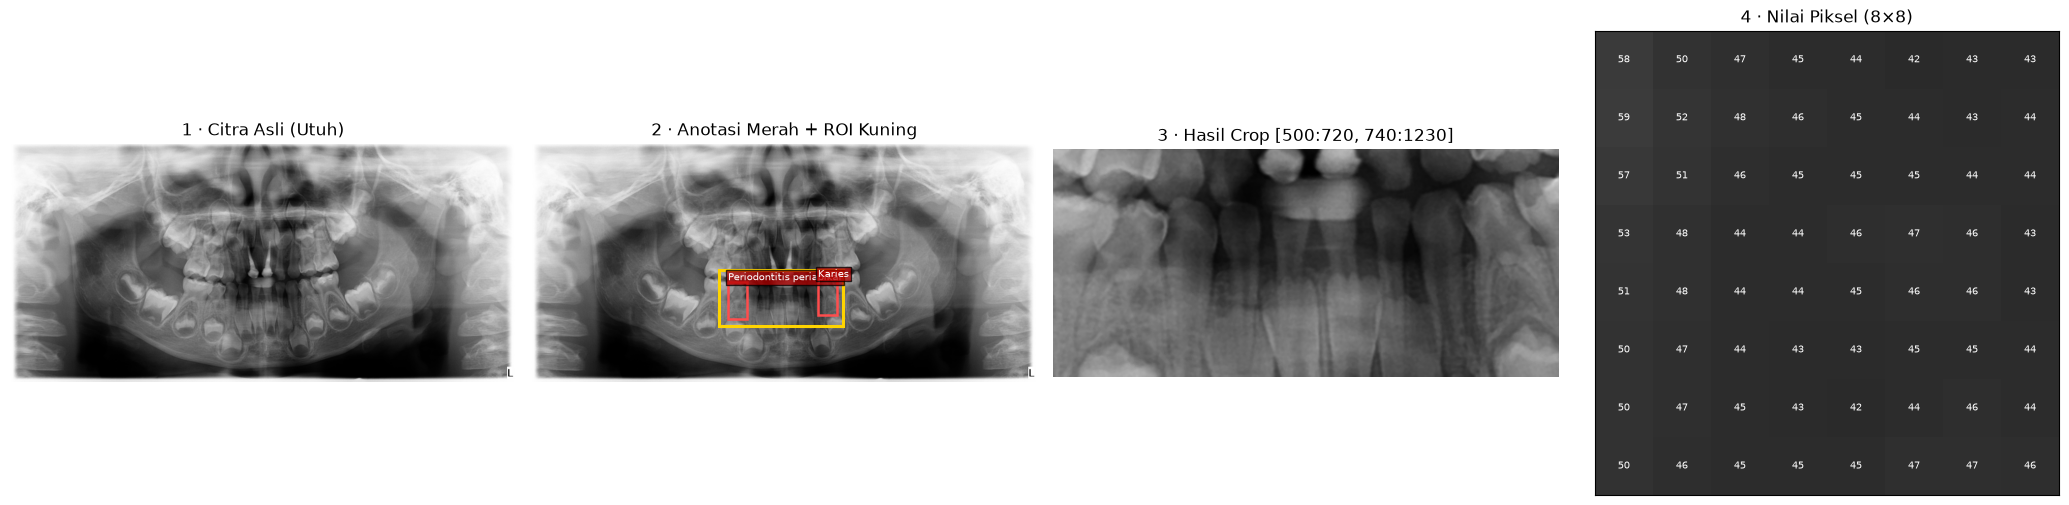

Dimensi area crop latihan: (220, 490, 3)


In [33]:
CASE_ID = "test_cate1_012"
ROI = [740, 500, 1230, 720]

if "load_case" not in globals() or "show_roi" not in globals():
    raise RuntimeError("Jalankan sel setup dan helper terlebih dahulu.")
case_latihan = load_case(CASE_ID)
opg_latihan = case_latihan["image"]
crop_latihan = show_roi(opg_latihan, ROI, case_latihan["annotations"])
print("Dimensi area crop latihan:", crop_latihan.shape)

### ✅ Self-check Otomatis

Sel di bawah ini tidak bertujuan untuk menilai interpretasi klinis radiograf Anda. Sel ini murni bertugas memverifikasi kondisi teknis pemrograman: kasus yang dimuat sudah tepat, area ROI tidak kosong, seluruh batas koordinat berada di dalam ukuran citra, dan tipe data array telah sesuai.

In [34]:
if "opg_latihan" not in globals() or "crop_latihan" not in globals():
    raise RuntimeError("Jalankan sel tantangan kasus kedua terlebih dahulu.")
tinggi, lebar = opg_latihan.shape[:2]
x1, y1, x2, y2 = ROI

assert CASE_ID == "test_cate1_012", "Gunakan kasus latihan yang diminta."
assert 0 <= x1 < x2 <= lebar and 0 <= y1 < y2 <= tinggi, "Koordinat ROI berada di luar batas ukuran citra."
assert crop_latihan.size > 0, "Koordinat ROI menghasilkan area crop yang kosong."
assert opg_latihan.dtype == np.uint8, "Format citra seharusnya bertipe data uint8."
print("Checkpoint teknis lulus.")

Checkpoint teknis lulus.


<details>
<summary><strong>✅ Buka solusi latihan fill-in-the-blank setelah mencoba</strong></summary>

```python
CASE_ID = "test_cate1_012"
ROI = [740, 500, 1230, 720]
crop = image[500:720, 740:1230]
```

**Mengapa urutan indeks pada baris terakhir tampak terbalik?**  
Koordinat *bounding box* menggunakan sistem kartesius `(x, y)` (horizontal mendahului vertikal), sedangkan array matriks pada Python selalu diakses berdasarkan kaidah `[baris, kolom]` atau `[y, x]`.

*Catatan:* Koordinat di atas bukanlah satu-satunya pilihan ROI yang valid. Pilihan koordinat Anda tetap benar selama masih berada di dalam batas ukuran citra, luas potongannya tidak nol, dan tujuan pengamatan areanya dapat dijelaskan.
</details>

## Glosarium Istilah Komputasi & Pengolahan Citra

| Istilah | Penjelasan Ringkas |
|---|---|
| **Array** | Struktur data berbentuk susunan atau matriks angka dengan dimensi tertentu |
| **Assignment** | Perintah menetapkan dan menyimpan suatu nilai ke dalam variabel menggunakan simbol `=` |
| **Indeks (*Index*)** | Posisi urutan elemen dalam struktur data; di Python selalu dimulai dari angka 0 |
| **Shape** | Ukuran dimensi matriks array, misalnya `(tinggi, lebar, kanal)` pada citra |
| **Dtype** | Tipe data numerik elemen array, misalnya `uint8` untuk rentang bilangan bulat 0–255 |
| **Piksel** | Unsur gambar terkecil pada citra digital yang membawa nilai intensitas derajat keabuan |
| **Bounding Box** | Kotak pembatas dengan format koordinat `[x1, y1, x2, y2]` untuk menandai lokasi objek atau lesi |
| **ROI (*Region of Interest*)** | Wilayah atau area anatomis tertentu pada citra yang menjadi fokus pengamatan |
| **Slicing** | Teknik memotong atau mengambil sebagian elemen dari array matriks, misalnya `[y1:y2, x1:x2]` |
| **Histogram** | Grafik distribusi frekuensi yang menghitung jumlah sebaran piksel pada setiap tingkat intensitas |
| **CLAHE** | Metode perataan histogram adaptif lokal yang membatasi penguatan kontras agar derau tidak berlebihan |
| **Checksum SHA-256** | Sidik jari digital unik untuk memverifikasi keaslian dan integritas berkas data |

## Exit Ticket — Jawab Empat Pertanyaan Evaluasi Mandiri

1. Tuliskan satu baris kode Python untuk mengambil area ROI `[x1, y1, x2, y2]` dari sebuah array citra bernama `image`.
2. Apa makna praktis dari informasi dimensi `shape = (942, 2000, 3)` pada sebuah citra?
3. Sebutkan satu manfaat klinis dan satu risiko teknis dari penerapan metode CLAHE pada radiograf panoramik.
4. Mengapa radiograf asli milik pasien tidak boleh diunggah ke Google Colab sebagai pengganti materi latihan ini?

💡 **Bahan Refleksi untuk Sesi 2:**  
Pikirkan satu contoh bagaimana pemilihan area ROI atau penerapan peningkatan kontras dapat memengaruhi apa yang diamati oleh dokter maupun model kecerdasan buatan (AI).

---

## Sumber Referensi dan Batasan Interpretasi Data

- **Dataset Publik:** [Children's Dental Panoramic Radiographs Dataset](https://doi.org/10.6084/m9.figshare.c.6317013.v1).
- **Publikasi Ilmiah Pendukung:** [Scientific Data 10, 380 (2023)](https://doi.org/10.1038/s41597-023-02237-5).
- **Karakteristik Anotasi:** Seluruh label dan kotak pembatas berasal dari anotator dataset publik terbuka, sehingga wajar bila terdapat variabilitas antarpengamat (*inter-observer variability*).
- **Batasan Generalisasi:** Penggunaan data panoramik anak-anak (pediatrik) dalam format kompresi PNG tentu memiliki batasan dan tidak dapat digeneralisasikan secara langsung ke populasi pasien dewasa, modalitas radiologi lain, ataupun protokol akuisisi berbeda di fasilitas klinis Anda.

*Keamanan Data:* Notebook ini tidak mengunggah data lokal ke peladen eksternal mana pun secara otomatis. Perintah unduhan hanya mengakses aset publik resmi yang tertera pada manifest, dan setiap berkas citra selalu divalidasi keutuhannya menggunakan SHA-256 sebelum digunakan.